# Notebook 10 — EfficientNet-B0 Training on RA + MURA Combined Dataset (Google Colab)

**Project:** P63 – Multimodal Deep Learning for Autoimmune Disease Diagnosis  
**Phase:** Binary RA vs Control Classification — EfficientNet-B0 Baseline

---

## Purpose

Train an **EfficientNet-B0** binary classifier on the **same balanced dataset** used for ResNet-18 and VGG16:

- **Class 1 (RA):** 1120 RA images from RAM-H1200-v1 dataset (`isRA==1` only)
- **Class 0 (Control):** 1120 MURA-negative normal hand X-rays
- **Total:** 2240 images (Train=1438, Val=272, Test=530)

---

## Important Notes

- This notebook uses the **SAME train/validation/test manifests** as Notebooks 08 (ResNet-18) and 09 (VGG16)
- This is an **IMAGE-ONLY** experiment (no clinical data, no multimodal fusion)
- Model comparison will be done LATER after all three models are trained
- This notebook is designed for **Google Colab** with automatic path handling
- EfficientNet-B0 checkpoint saved separately to `models/ra_mura_efficientnet_b0/`

---

## Colab Setup

This notebook will:
1. ✅ Detect GPU availability
2. ✅ Auto-detect or set PROJECT_ROOT
3. ✅ Convert Windows paths to Colab paths automatically
4. ✅ Verify all required files exist before training
5. ✅ Save outputs to separate directory

**Estimated Runtime:** 30-60 minutes on Colab T4 GPU

In [2]:
# ============================================================================
# Section 0 — Setup and Clone Repository (COLAB ONLY)
# ============================================================================

import sys
from pathlib import Path

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("=" * 70)
    print("STEP 1/7: COLAB ENVIRONMENT DETECTED")
    print("=" * 70)
    print("✓ Running in Google Colab")
    print()

    # ── Step 2: Install Git LFS ─────────────────────────────────────────
    print("=" * 70)
    print("STEP 2/7: INSTALLING GIT LFS")
    print("=" * 70)
    !curl -s https://packagecloud.io/install/repositories/github/git-lfs/script.deb.sh | bash
    !apt-get install git-lfs -y
    !git lfs install
    print("✓ Git LFS installed")
    print()

    # ── Step 3: Check if repo already cloned ────────────────────────────
    print("=" * 70)
    print("STEP 3/7: CHECKING EXISTING REPOSITORY")
    print("=" * 70)

    if Path('/content/FYP').exists():
        print("⚠️  Repository already exists at /content/FYP")
        print("Skipping clone. If you need a fresh clone, manually remove it first.")
    else:
        print("Repository not found. Will clone in next step.")
    print()

    # ── Step 4: Clone repository ─────────────────────────────────────────
    print("=" * 70)
    print("STEP 4/7: CLONING REPOSITORY")
    print("=" * 70)

    if not Path('/content/FYP').exists():
        %cd /content
        !git clone https://github.com/Varshini-3012/FYP.git
        print("✓ Repository cloned")
    else:
        print("⊘ Skipped (already exists)")
    print()

    # ── Step 5: Verify LFS files ─────────────────────────────────────────
    print("=" * 70)
    print("STEP 5/7: VERIFYING GIT LFS FILES")
    print("=" * 70)

    # Check if images are actual files or LFS pointers
    sample_ra_dir = Path('/content/FYP/Dataset/ra/RAM-H1200_RA')
    if sample_ra_dir.exists():
        test_files = list(sample_ra_dir.glob('*.png'))[:3]
        if test_files:
            sizes = [f.stat().st_size for f in test_files]
            print(f"Sample RA file sizes: {sizes} bytes")

            if any(s < 1000 for s in sizes):
                print("⚠️  Files are LFS pointer files (< 1KB)")
                print("Running git lfs pull to download actual images...")
                %cd /content/FYP
                !git lfs pull
                print("✓ LFS files downloaded")
            else:
                print("✓ Files are already downloaded (not LFS pointers)")
        else:
            print("⚠️  No PNG files found in sample directory")
    else:
        print(f"⚠️  Sample directory not found: {sample_ra_dir}")
    print()

    # ── Step 6: Set PROJECT_ROOT ─────────────────────────────────────────
    print("=" * 70)
    print("STEP 6/7: SETTING PROJECT ROOT")
    print("=" * 70)

    PROJECT_ROOT = Path('/content/FYP')
    print(f"PROJECT_ROOT: {PROJECT_ROOT}")
    print(f"Exists: {PROJECT_ROOT.exists()}")

    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    print("✓ Added to sys.path")
    print()

    # ── Step 7: Summary ──────────────────────────────────────────────────
    print("=" * 70)
    print("STEP 7/7: SETUP SUMMARY")
    print("=" * 70)
    print(f"✓ Git LFS: Installed")
    print(f"✓ Repository: {PROJECT_ROOT}")
    print(f"✓ Dataset: {PROJECT_ROOT / 'Dataset'}")
    print(f"✓ Manifests: {PROJECT_ROOT / 'outputs/manifests'}")
    print()
    print("🎉 Setup complete! Ready to train.")
    print("=" * 70)

else:
    print("⊘ Not running in Colab - skipping setup")
    PROJECT_ROOT = Path('..').resolve()
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))


STEP 1/7: COLAB ENVIRONMENT DETECTED
✓ Running in Google Colab

STEP 2/7: INSTALLING GIT LFS
Detected operating system as Ubuntu/noble.
Checking for curl...
Detected curl...
Checking for gpg...
Detected gpg...
Detected apt version as 2.8.3
Running apt-get update... done.
Installing apt-transport-https... done.
Installing /etc/apt/sources.list.d/github_git-lfs.list...done.
Importing packagecloud gpg key... Packagecloud gpg key imported to /etc/apt/keyrings/github_git-lfs-archive-keyring.gpg
done.
Running apt-get update... done.

The repository is setup! You can now install packages.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 90 not upgraded.
Need to get 9,621 kB of archives.
After this operation, 20.6 MB of additional disk space will be used.
Get:1 https://packagecloud.io/github/git-lfs/ubuntu noble/main amd64 git-lfs amd64 3.8.0 [9

---
## Section 1 — Environment Detection and Project Root Setup

In [3]:
import sys
from pathlib import Path

print("=" * 70)
print("ENVIRONMENT DETECTION")
print("=" * 70)

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("✓ Running in Google Colab")

    # Try to auto-detect PROJECT_ROOT
    if Path('/content/FYP').exists():
        PROJECT_ROOT = Path('/content/FYP')
        print(f"✓ Auto-detected PROJECT_ROOT: {PROJECT_ROOT}")
    elif Path('/content/drive/MyDrive/FYP').exists():
        PROJECT_ROOT = Path('/content/drive/MyDrive/FYP')
        print(f"✓ Auto-detected PROJECT_ROOT: {PROJECT_ROOT}")
    else:
        print("❌ Could not auto-detect PROJECT_ROOT")
        print("Please set PROJECT_ROOT manually in the cell below.")
        print("\nExample:")
        print("  PROJECT_ROOT = Path('/content/FYP')  # If cloned to /content")
        print("  PROJECT_ROOT = Path('/content/drive/MyDrive/FYP')  # If in Google Drive")
        raise FileNotFoundError("PROJECT_ROOT not found. Set it manually above.")
else:
    print("⊘ Running locally (not Colab)")
    PROJECT_ROOT = Path('..').resolve()
    print(f"✓ Using local PROJECT_ROOT: {PROJECT_ROOT}")

# Add to sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"\nPROJECT_ROOT: {PROJECT_ROOT}")
print(f"Exists: {PROJECT_ROOT.exists()}")
print("=" * 70)

ENVIRONMENT DETECTION
✓ Running in Google Colab
✓ Auto-detected PROJECT_ROOT: /content/FYP

PROJECT_ROOT: /content/FYP
Exists: True


### Manual PROJECT_ROOT Override (if needed)

If auto-detection failed, uncomment and set PROJECT_ROOT manually:

In [4]:
# Uncomment ONE of these if auto-detection failed:
# PROJECT_ROOT = Path('/content/FYP')  # If project is in /content
# PROJECT_ROOT = Path('/content/drive/MyDrive/FYP')  # If project is in Google Drive

# Then re-run the cell above to verify

### Mount Google Drive (Optional)

If your project is in Google Drive, mount it first:

In [5]:
# Uncomment to mount Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# print("✓ Google Drive mounted")

---
## Section 2 — Library Versions and GPU Verification

In [6]:
import torch
import torchvision

print("=" * 70)
print("LIBRARY VERSIONS")
print("=" * 70)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print()

print("=" * 70)
print("GPU / DEVICE VERIFICATION")
print("=" * 70)
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    device = torch.device('cuda')
    print(f"\n✓ Selected device: {device}")
    print("✓ Model will train on GPU")
else:
    device = torch.device('cpu')
    print(f"\n⚠ Selected device: {device}")
    print("⚠ Model will train on CPU (will be slow)")
    print("⚠ Consider enabling GPU: Runtime > Change runtime type > Hardware accelerator > GPU")

print("=" * 70)

LIBRARY VERSIONS
Python: 3.13.15
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128

GPU / DEVICE VERIFICATION
CUDA available: True
CUDA version: 12.8
GPU name: Tesla T4
GPU memory: 15.64 GB
Number of GPUs: 1

✓ Selected device: cuda
✓ Model will train on GPU


---
## Section 3 — Project Structure Verification

In [7]:
print("=" * 70)
print("PROJECT STRUCTURE VERIFICATION")
print("=" * 70)

# Define expected directories
required_dirs = [
    PROJECT_ROOT / 'Dataset' / 'ra' / 'Segmentation',
    PROJECT_ROOT / 'Dataset' / 'mura_controls',
    PROJECT_ROOT / 'outputs' / 'manifests' / 'ra_mura_combined',
    PROJECT_ROOT / 'outputs' / 'plots',
    PROJECT_ROOT / 'models',
]

all_exist = True
for dir_path in required_dirs:
    exists = dir_path.exists()
    symbol = "✓" if exists else "❌"
    print(f"{symbol} {dir_path.relative_to(PROJECT_ROOT)}")
    if not exists:
        all_exist = False

print()
if not all_exist:
    print("❌ ERROR: Required directories missing!")
    print("Please check PROJECT_ROOT is set correctly.")
    raise FileNotFoundError("Required project directories not found")
else:
    print("✓ All required directories exist")

print("=" * 70)

PROJECT STRUCTURE VERIFICATION
✓ Dataset/ra/Segmentation
✓ Dataset/mura_controls
✓ outputs/manifests/ra_mura_combined
✓ outputs/plots
✓ models

✓ All required directories exist


---
## Section 4 — Imports and Configuration

In [8]:
import os
import json
import random
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision import models

sns.set_theme(style='whitegrid', palette='muted')
Image.MAX_IMAGE_PIXELS = None

print("✓ All imports successful")

✓ All imports successful


### Define Paths and Create Output Directories

In [9]:
# ── Paths ─────────────────────────────────────────────────────────────────────
COMBINED_MAN_DIR = PROJECT_ROOT / 'outputs' / 'manifests' / 'ra_mura_combined'
PLOTS_DIR        = PROJECT_ROOT / 'outputs' / 'plots'
METRICS_DIR      = PROJECT_ROOT / 'outputs' / 'metrics' / 'ra_mura_efficientnet_b0'
MODEL_SAVE_DIR   = PROJECT_ROOT / 'models' / 'ra_mura_efficientnet_b0'

# Create output directories
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directories created:")
print(f"  Models: {MODEL_SAVE_DIR.relative_to(PROJECT_ROOT)}")
print(f"  Metrics: {METRICS_DIR.relative_to(PROJECT_ROOT)}")
print(f"  Plots: {PLOTS_DIR.relative_to(PROJECT_ROOT)}")

Output directories created:
  Models: models/ra_mura_efficientnet_b0
  Metrics: outputs/metrics/ra_mura_efficientnet_b0
  Plots: outputs/plots


### Configuration (Same as ResNet-18)

In [10]:
# ── Configuration (SAME AS RESNET-18) ────────────────────────────────────────
RANDOM_SEED  = 42
IMG_SIZE     = (224, 224)  # EfficientNet-B0 native size
BATCH_SIZE   = 16
NUM_EPOCHS   = 20
LR           = 0.0001
WEIGHT_DECAY = 0.0001
PATIENCE     = 7
DROPOUT      = 0.5

# RA dataset-specific normalization (from ResNet-18 experiment)
MEAN_VALS = [0.2503633202338705, 0.2503633202338705, 0.2503633202338705]
STD_VALS  = [0.2531105167199891, 0.2531105167199891, 0.2531105167199891]

# Expected counts (for verification)
EXPECTED_COUNTS = {
    'train': {'ra': 719, 'control': 719, 'total': 1438},
    'val'  : {'ra': 136, 'control': 136, 'total': 272},
    'test' : {'ra': 265, 'control': 265, 'total': 530},
}

# Reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

print("Configuration:")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {PATIENCE}")
print(f"  Device: {device}")

Configuration:
  Random seed: 42
  Image size: (224, 224)
  Batch size: 16
  Learning rate: 0.0001
  Epochs: 20
  Early stopping patience: 7
  Device: cuda


---
## Section 5 — Load and Verify Manifests

In [11]:
print("=" * 70)
print("LOADING COMBINED MANIFESTS (SAME AS RESNET-18 & VGG16)")
print("=" * 70)

train_csv = COMBINED_MAN_DIR / 'train_combined_manifest.csv'
val_csv   = COMBINED_MAN_DIR / 'val_combined_manifest.csv'
test_csv  = COMBINED_MAN_DIR / 'test_combined_manifest.csv'

# Verify manifests exist
for path in [train_csv, val_csv, test_csv]:
    if not path.exists():
        raise FileNotFoundError(f'❌ Manifest not found: {path}')
    print(f'✓ Found: {path.name}')

# Load manifests
combined_train = pd.read_csv(train_csv)
combined_val   = pd.read_csv(val_csv)
combined_test  = pd.read_csv(test_csv)

print()
print(f'Loaded manifests:')
print(f'  Train: {len(combined_train)} rows')
print(f'  Val  : {len(combined_val)} rows')
print(f'  Test : {len(combined_test)} rows')
print(f'  Total: {len(combined_train) + len(combined_val) + len(combined_test)} rows')

# Verify columns
required_cols = ['filename', 'full_path', 'split', 'label', 'source', 'patient_id']
for col in required_cols:
    if col not in combined_train.columns:
        raise ValueError(f"❌ Required column '{col}' not found in manifest")

print(f"\n✓ All required columns present")
print("=" * 70)

LOADING COMBINED MANIFESTS (SAME AS RESNET-18 & VGG16)
✓ Found: train_combined_manifest.csv
✓ Found: val_combined_manifest.csv
✓ Found: test_combined_manifest.csv

Loaded manifests:
  Train: 1438 rows
  Val  : 272 rows
  Test : 530 rows
  Total: 2240 rows

✓ All required columns present


---
## Section 6 — Path Conversion for Colab

In [12]:
print("=" * 70)
print("PATH CONVERSION FOR COLAB")
print("=" * 70)

if IN_COLAB:
    print("Converting Windows paths to Colab Linux paths...")

    n_converted = 0
    for df in [combined_train, combined_val, combined_test]:
        # Check if paths need conversion
        sample_path = str(df.iloc[0]['full_path'])

        if 'c:\\' in sample_path.lower() or 'c:/' in sample_path.lower():
            # Convert Windows paths to Colab paths
            df['full_path'] = df['full_path'].astype(str).str.replace(
                r'c:\\Users\\varsh\\OneDrive\\Documents\\FYP',
                str(PROJECT_ROOT),
                case=False,
                regex=False
            ).str.replace(
                r'c:/Users/varsh/OneDrive/Documents/FYP',
                str(PROJECT_ROOT),
                case=False,
                regex=False
            ).str.replace('\\\\', '/').str.replace('\\', '/')

            n_converted += len(df)

    print(f"✓ Converted {n_converted} paths from Windows to Linux format")

    # Show sample path
    print(f"\nSample path after conversion:")
    print(f"  {combined_train.iloc[0]['full_path']}")
else:
    print("⊘ Running locally - no path conversion needed")

print("=" * 70)

PATH CONVERSION FOR COLAB
Converting Windows paths to Colab Linux paths...
✓ Converted 2240 paths from Windows to Linux format

Sample path after conversion:
  c:/Users/varsh/OneDrive/Documents/FYP/Dataset/ra/Segmentation/train/JP_HMCRD_P0176_20160117_1884_R.bmp


---
## Section 7 — Dataset Verification

In [14]:
print("=" * 70)
print("PATH CONVERSION FOR COLAB")
print("=" * 70)

# Convert Windows paths to Linux paths for Colab
def convert_path(path_str):
    """Convert any Windows path format to Linux Colab format"""
    path_str = str(path_str)

    # Replace Windows base path with Colab path (handle all variants)
    replacements = [
        ('c:\\Users\\varsh\\OneDrive\\Documents\\FYP', '/content/FYP'),
        ('C:\\Users\\varsh\\OneDrive\\Documents\\FYP', '/content/FYP'),
        ('c:/Users/varsh/OneDrive/Documents/FYP', '/content/FYP'),
        ('C:/Users/varsh/OneDrive/Documents/FYP', '/content/FYP'),
    ]

    for old, new in replacements:
        path_str = path_str.replace(old, new)

    # Convert remaining backslashes to forward slashes
    path_str = path_str.replace('\\', '/')

    return path_str

# Show BEFORE conversion
print("BEFORE conversion (sample):")
print(f"  {combined_train.iloc[0]['full_path']}")
print()

# Apply conversion to all DataFrames
combined_train['full_path'] = combined_train['full_path'].apply(convert_path)
combined_val['full_path'] = combined_val['full_path'].apply(convert_path)
combined_test['full_path'] = combined_test['full_path'].apply(convert_path)

# Recreate combined_all after conversion
combined_all = pd.concat([combined_train, combined_val, combined_test], ignore_index=True)

# Show AFTER conversion
print("AFTER conversion (sample):")
print(f"  {combined_train.iloc[0]['full_path']}")
print()

print(f"✓ Converted {len(combined_all)} paths from Windows to Linux format")
print("=" * 70)


PATH CONVERSION FOR COLAB
BEFORE conversion (sample):
  c:/Users/varsh/OneDrive/Documents/FYP/Dataset/ra/Segmentation/train/JP_HMCRD_P0176_20160117_1884_R.bmp

AFTER conversion (sample):
  /content/FYP/Dataset/ra/Segmentation/train/JP_HMCRD_P0176_20160117_1884_R.bmp

✓ Converted 2240 paths from Windows to Linux format


---
## Section 8 — Image Preprocessing and Transforms

In [15]:
print("Defining image transforms (SAME AS RESNET-18)...")
print()

def get_transforms(split, img_size, mean, std):
    """
    Return transform pipeline.

    Training: Augmentation + resize + normalize
    Val/Test: Resize + normalize only
    """
    normalize = T.Normalize(mean=mean, std=std)

    if split == 'train':
        return T.Compose([
            T.Resize(img_size),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(10),
            T.ColorJitter(brightness=0.2, contrast=0.2),
            T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            T.ToTensor(),
            normalize,
        ])
    else:
        return T.Compose([
            T.Resize(img_size),
            T.ToTensor(),
            normalize,
        ])

train_transform = get_transforms('train', IMG_SIZE, MEAN_VALS, STD_VALS)
val_transform   = get_transforms('val',   IMG_SIZE, MEAN_VALS, STD_VALS)
test_transform  = get_transforms('test',  IMG_SIZE, MEAN_VALS, STD_VALS)

print('Transforms defined:')
print(f'  Input size: {IMG_SIZE}')
print(f'  Normalization: RA dataset-specific')
print(f'    Mean: {MEAN_VALS[0]:.4f} (all channels)')
print(f'    Std:  {STD_VALS[0]:.4f} (all channels)')
print(f'  Training augmentation: HFlip, Rotation(±10°), ColorJitter, Translate')
print(f'  Val/Test: Resize only (no augmentation)')

Defining image transforms (SAME AS RESNET-18)...

Transforms defined:
  Input size: (224, 224)
  Normalization: RA dataset-specific
    Mean: 0.2504 (all channels)
    Std:  0.2531 (all channels)
  Training augmentation: HFlip, Rotation(±10°), ColorJitter, Translate
  Val/Test: Resize only (no augmentation)


---
## Section 9 — Dataset and DataLoader Creation

In [16]:
class CombinedRAMURADataset(Dataset):
    """
    PyTorch Dataset for combined RA + MURA control images.

    Reads manifest CSV and loads images on-the-fly.
    Converts all images to RGB (3-channel) for EfficientNet-B0.
    """
    def __init__(self, manifest_df, transform=None):
        self.manifest  = manifest_df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row   = self.manifest.iloc[idx]
        path  = Path(row['full_path'])
        label = int(row['label'])

        # Load and convert to RGB
        img = Image.open(path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

# Create datasets
train_dataset = CombinedRAMURADataset(combined_train, transform=train_transform)
val_dataset   = CombinedRAMURADataset(combined_val,   transform=val_transform)
test_dataset  = CombinedRAMURADataset(combined_test,  transform=test_transform)

# Create dataloaders (num_workers=2 safe for Colab)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Datasets created:')
print(f'  Train: {len(train_dataset)} images, {len(train_loader)} batches')
print(f'  Val  : {len(val_dataset)} images, {len(val_loader)} batches')
print(f'  Test : {len(test_dataset)} images, {len(test_loader)} batches')

Datasets created:
  Train: 1438 images, 90 batches
  Val  : 272 images, 17 batches
  Test : 530 images, 34 batches


---
## Section 10 — EfficientNet-B0 Model Definition

In [17]:
print("=" * 70)
print("DEFINING EFFICIENTNET-B0 MODEL")
print("=" * 70)
print()

class BinaryEfficientNetB0(nn.Module):
    def __init__(self, dropout=0.5, pretrained=True):
        super().__init__()

        # Load pretrained EfficientNet-B0
        self.backbone = models.efficientnet_b0(pretrained=pretrained)

        # Get number of features from classifier
        in_features = self.backbone.classifier[1].in_features

        # Replace classifier for binary classification
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, 1)
        )

    def forward(self, x):
        return self.backbone(x)

# Create model
print("Creating EfficientNet-B0 model...")
print(f"  Pretrained: True (ImageNet)")
print(f"  Dropout: {DROPOUT}")
print()

model = BinaryEfficientNetB0(dropout=DROPOUT, pretrained=True).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: EfficientNet-B0")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print()
print("Model architecture:")
print(model)
print("=" * 70)

DEFINING EFFICIENTNET-B0 MODEL

Creating EfficientNet-B0 model...
  Pretrained: True (ImageNet)
  Dropout: 0.5

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 126MB/s]


Model: EfficientNet-B0
Total parameters: 4,008,829
Trainable parameters: 4,008,829

Model architecture:
BinaryEfficientNetB0(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv

---
## Section 11 — Device Verification

In [18]:
print("=" * 70)
print("DEVICE VERIFICATION")
print("=" * 70)

# Verify model is on correct device
model_device = next(model.parameters()).device
print(f"Model device: {model_device}")

if str(model_device) != str(device):
    print(f"⚠ WARNING: Model device ({model_device}) != selected device ({device})")
    print("Moving model to correct device...")
    model = model.to(device)
    model_device = next(model.parameters()).device
    print(f"✓ Model moved to: {model_device}")
else:
    print(f"✓ Model is on correct device: {device}")

# Test forward pass with dummy data
print("\nTesting forward pass with dummy batch...")
dummy_input = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    dummy_output = model(dummy_input)

print(f"✓ Forward pass successful")
print(f"  Input shape: {dummy_input.shape}")
print(f"  Output shape: {dummy_output.shape}")
print(f"  Output device: {dummy_output.device}")

print("\n" + "=" * 70)
print("✓ DEVICE VERIFICATION PASSED")
print("=" * 70)

DEVICE VERIFICATION
Model device: cuda:0
⚠ WARNING: Model device (cuda:0) != selected device (cuda)
Moving model to correct device...
✓ Model moved to: cuda:0

Testing forward pass with dummy batch...
✓ Forward pass successful
  Input shape: torch.Size([2, 3, 224, 224])
  Output shape: torch.Size([2, 1])
  Output device: cuda:0

✓ DEVICE VERIFICATION PASSED


---
## Section 12 — Training Configuration

In [19]:
print("=" * 70)
print("TRAINING CONFIGURATION (SAME AS RESNET-18)")
print("=" * 70)

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer (same as ResNet-18)
optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

print(f"Loss function: BCEWithLogitsLoss")
print(f"Optimizer: Adam")
print(f"  Learning rate: {LR}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"\nTraining parameters:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early stopping patience: {PATIENCE}")
print(f"  Checkpoint criterion: Best validation loss")
print(f"\nCheckpoint will be saved to:")
print(f"  {MODEL_SAVE_DIR / 'efficientnet_b0_best.pth'}")
print("=" * 70)

TRAINING CONFIGURATION (SAME AS RESNET-18)
Loss function: BCEWithLogitsLoss
Optimizer: Adam
  Learning rate: 0.0001
  Weight decay: 0.0001

Training parameters:
  Epochs: 20
  Early stopping patience: 7
  Checkpoint criterion: Best validation loss

Checkpoint will be saved to:
  /content/FYP/models/ra_mura_efficientnet_b0/efficientnet_b0_best.pth


---
## Section 13 — Training Loop

In [20]:
print("=" * 70)
print("TRAINING EFFICIENTNET-B0")
print("=" * 70)
print()

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

for epoch in range(1, NUM_EPOCHS + 1):
    # ─────────────────────────────────────────────────────────────────────────
    # Training phase
    # ─────────────────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move to device
        inputs = inputs.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Metrics
        train_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss / train_total
    train_acc = train_correct / train_total

    # ─────────────────────────────────────────────────────────────────────────
    # Validation phase
    # ─────────────────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss / val_total
    val_acc = val_correct / val_total

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Print epoch results
    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  "
          f"Train: {train_loss:.4f}/{train_acc:.4f}  "
          f"Val: {val_loss:.4f}/{val_acc:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_SAVE_DIR / 'efficientnet_b0_best.pth')
        print(f"  → Best model saved (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs")
            print(f"Best epoch: {best_epoch} (val_loss: {best_val_loss:.4f})")
            break

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Best epoch: {best_epoch}/{NUM_EPOCHS}")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Final validation accuracy: {history['val_acc'][best_epoch-1]:.4f}")
print(f"\nBest model saved to:")
print(f"  {MODEL_SAVE_DIR / 'efficientnet_b0_best.pth'}")
print("=" * 70)

TRAINING EFFICIENTNET-B0

Epoch  1/20  Train: 0.2255/0.9346  Val: 0.0207/1.0000
  → Best model saved (val_loss: 0.0207)
Epoch  2/20  Train: 0.0429/0.9875  Val: 0.0045/1.0000
  → Best model saved (val_loss: 0.0045)
Epoch  3/20  Train: 0.0193/0.9986  Val: 0.0025/1.0000
  → Best model saved (val_loss: 0.0025)
Epoch  4/20  Train: 0.0147/0.9972  Val: 0.0011/1.0000
  → Best model saved (val_loss: 0.0011)
Epoch  5/20  Train: 0.0094/0.9986  Val: 0.0004/1.0000
  → Best model saved (val_loss: 0.0004)
Epoch  6/20  Train: 0.0048/0.9993  Val: 0.0006/1.0000
Epoch  7/20  Train: 0.0032/1.0000  Val: 0.0006/1.0000
Epoch  8/20  Train: 0.0035/1.0000  Val: 0.0005/1.0000
Epoch  9/20  Train: 0.0138/0.9937  Val: 0.0003/1.0000
  → Best model saved (val_loss: 0.0003)
Epoch 10/20  Train: 0.0063/0.9986  Val: 0.0004/1.0000
Epoch 11/20  Train: 0.0019/1.0000  Val: 0.0001/1.0000
  → Best model saved (val_loss: 0.0001)
Epoch 12/20  Train: 0.0011/1.0000  Val: 0.0003/1.0000
Epoch 13/20  Train: 0.0010/1.0000  Val: 0.0001

---
## Section 14 — Training History Plots

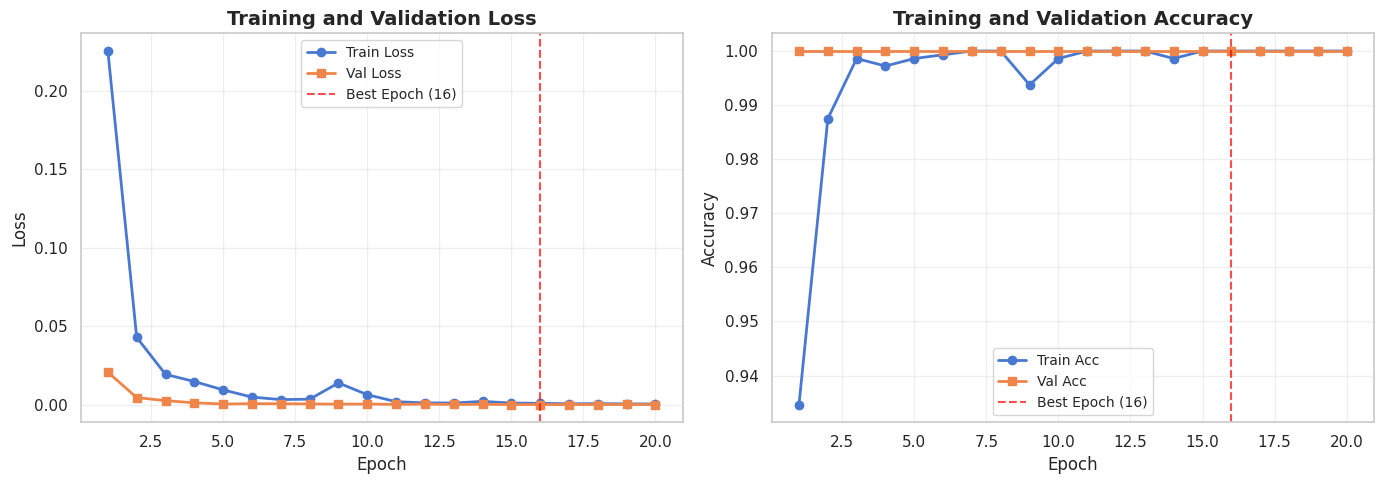

✓ Training history plot saved to: /content/FYP/outputs/plots/10_training_history.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'o-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 's-', label='Val Loss', linewidth=2)
axes[0].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'], 'o-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'], 's-', label='Val Acc', linewidth=2)
axes[1].axvline(best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '10_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Training history plot saved to: {PLOTS_DIR / '10_training_history.png'}")

---
## Section 15 — Load Best Model for Evaluation

In [22]:
print("=" * 70)
print("LOADING BEST MODEL FOR TEST EVALUATION")
print("=" * 70)

model.load_state_dict(torch.load(MODEL_SAVE_DIR / 'efficientnet_b0_best.pth', map_location=device))
model.eval()

print(f"✓ Loaded best model from epoch {best_epoch}")
print(f"  Checkpoint: {MODEL_SAVE_DIR / 'efficientnet_b0_best.pth'}")
print("=" * 70)

LOADING BEST MODEL FOR TEST EVALUATION
✓ Loaded best model from epoch 16
  Checkpoint: /content/FYP/models/ra_mura_efficientnet_b0/efficientnet_b0_best.pth


---
## Section 16 — Test Set Evaluation

In [23]:
print("=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)
print()

# Collect predictions
all_labels = []
all_preds = []
all_probs = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        probs = torch.sigmoid(outputs).squeeze()
        preds = (probs >= 0.5).float()

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds, zero_division=0)
test_rec = recall_score(all_labels, all_preds, zero_division=0)
test_f1 = f1_score(all_labels, all_preds, zero_division=0)
test_auc = roc_auc_score(all_labels, all_probs)
cm = confusion_matrix(all_labels, all_preds)

print("TEST SET RESULTS:")
print("-" * 70)
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1-Score  : {test_f1:.4f}")
print(f"ROC-AUC   : {test_auc:.4f}")
print()
print("Confusion Matrix:")
print(f"  TN={cm[0,0]:<4d} FP={cm[0,1]:<4d}")
print(f"  FN={cm[1,0]:<4d} TP={cm[1,1]:<4d}")
print()
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Control', 'RA'], zero_division=0))
print("=" * 70)

TEST SET EVALUATION

TEST SET RESULTS:
----------------------------------------------------------------------
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000
ROC-AUC   : 1.0000

Confusion Matrix:
  TN=265  FP=0   
  FN=0    TP=265 

Classification Report:
              precision    recall  f1-score   support

     Control       1.00      1.00      1.00       265
          RA       1.00      1.00      1.00       265

    accuracy                           1.00       530
   macro avg       1.00      1.00      1.00       530
weighted avg       1.00      1.00      1.00       530



---
## Section 17 — Confusion Matrix Plot

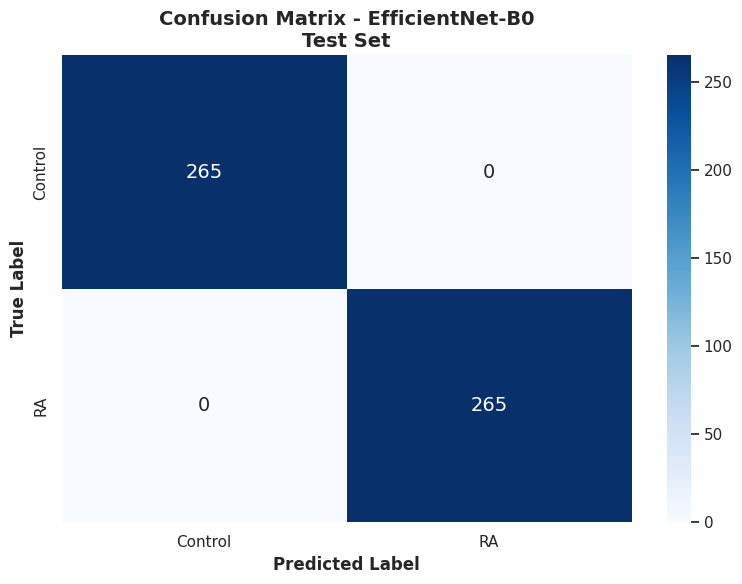

✓ Confusion matrix saved to: /content/FYP/outputs/plots/10_confusion_matrix.png


In [24]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Control', 'RA'],
            yticklabels=['Control', 'RA'],
            ax=ax, annot_kws={'fontsize': 14})

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - EfficientNet-B0\nTest Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '10_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Confusion matrix saved to: {PLOTS_DIR / '10_confusion_matrix.png'}")

---
## Section 18 — ROC Curve

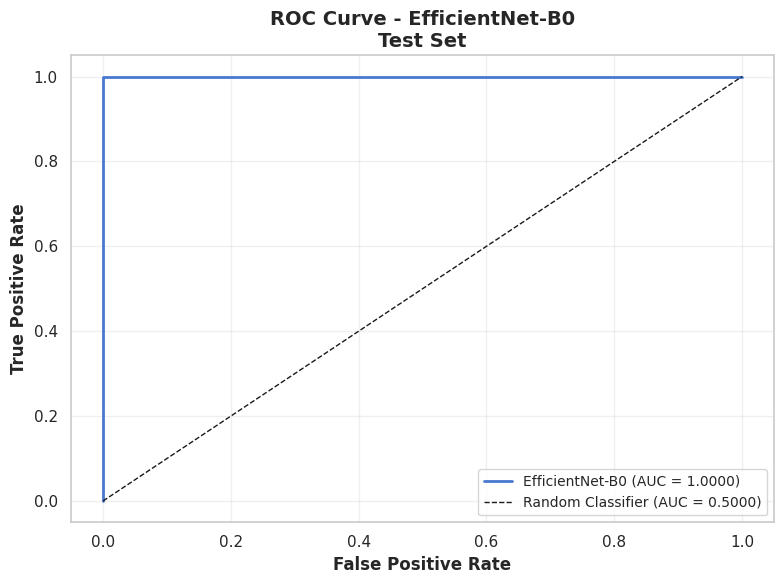

✓ ROC curve saved to: /content/FYP/outputs/plots/10_roc_curve.png


In [25]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, linewidth=2, label=f'EfficientNet-B0 (AUC = {test_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - EfficientNet-B0\nTest Set', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / '10_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ ROC curve saved to: {PLOTS_DIR / '10_roc_curve.png'}")

---
## Section 19 — Save Results

In [26]:
print("=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save test metrics
test_metrics = {
    'model': 'EfficientNet-B0',
    'test_accuracy': float(test_acc),
    'test_precision': float(test_prec),
    'test_recall': float(test_rec),
    'test_f1': float(test_f1),
    'test_roc_auc': float(test_auc),
    'confusion_matrix': cm.tolist(),
    'best_epoch': int(best_epoch),
    'best_val_loss': float(best_val_loss),
}

with open(METRICS_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

print(f"✓ Test metrics saved to: {METRICS_DIR / 'test_metrics.json'}")

# Save training history
with open(METRICS_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print(f"✓ Training history saved to: {METRICS_DIR / 'training_history.json'}")

# Save predictions
predictions_df = pd.DataFrame({
    'true_label': all_labels,
    'predicted_label': all_preds,
    'predicted_probability': all_probs
})
predictions_df.to_csv(METRICS_DIR / 'test_predictions.csv', index=False)

print(f"✓ Test predictions saved to: {METRICS_DIR / 'test_predictions.csv'}")

print("=" * 70)

SAVING RESULTS
✓ Test metrics saved to: /content/FYP/outputs/metrics/ra_mura_efficientnet_b0/test_metrics.json
✓ Training history saved to: /content/FYP/outputs/metrics/ra_mura_efficientnet_b0/training_history.json
✓ Test predictions saved to: /content/FYP/outputs/metrics/ra_mura_efficientnet_b0/test_predictions.csv


---
## Section 20 — Experiment Summary

In [27]:
print("\n" + "=" * 70)
print("EXPERIMENT SUMMARY")
print("=" * 70)
print()
print(f"Model: EfficientNet-B0")
print(f"Task: Binary RA vs Control Classification")
print(f"Experiment type: Image-only (no clinical data, no multimodal fusion)")
print(f"Device: {device}")
print()
print(f"Dataset:")
print(f"  Train samples: {len(train_dataset)} (719 RA + 719 Control)")
print(f"  Validation samples: {len(val_dataset)} (136 RA + 136 Control)")
print(f"  Test samples: {len(test_dataset)} (265 RA + 265 Control)")
print(f"  Total: {len(combined_all)} images")
print()
print(f"Training configuration:")
print(f"  Random seed: {RANDOM_SEED}")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Learning rate: {LR}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Optimizer: Adam")
print(f"  Loss: BCEWithLogitsLoss")
print()
print(f"Training results:")
print(f"  Best epoch: {best_epoch}/{NUM_EPOCHS}")
print(f"  Best validation loss: {best_val_loss:.4f}")
print(f"  Best validation accuracy: {history['val_acc'][best_epoch-1]:.4f}")
print()
print(f"Test set results:")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test Precision: {test_prec:.4f}")
print(f"  Test Recall: {test_rec:.4f}")
print(f"  Test F1-Score: {test_f1:.4f}")
print(f"  Test ROC-AUC: {test_auc:.4f}")
print()
print(f"Best checkpoint saved to:")
print(f"  {MODEL_SAVE_DIR / 'efficientnet_b0_best.pth'}")
print()
print(f"Outputs saved to:")
print(f"  Metrics: {METRICS_DIR}")
print(f"  Plots: {PLOTS_DIR} (10_*.png)")
print()
print("=" * 70)
print("✓✓✓ EFFICIENTNET-B0 TRAINING COMPLETE ✓✓✓")
print("=" * 70)
print()
print("Next steps:")
print("  1. Review training plots and metrics")
print("  2. Compare with ResNet-18 (Notebook 08) and VGG16 (Notebook 09) later")
print("  3. All three baselines must be complete before comparison analysis")
print("=" * 70)


EXPERIMENT SUMMARY

Model: EfficientNet-B0
Task: Binary RA vs Control Classification
Experiment type: Image-only (no clinical data, no multimodal fusion)
Device: cuda

Dataset:
  Train samples: 1438 (719 RA + 719 Control)
  Validation samples: 272 (136 RA + 136 Control)
  Test samples: 530 (265 RA + 265 Control)
  Total: 2240 images

Training configuration:
  Random seed: 42
  Image size: (224, 224)
  Batch size: 16
  Learning rate: 0.0001
  Weight decay: 0.0001
  Optimizer: Adam
  Loss: BCEWithLogitsLoss

Training results:
  Best epoch: 16/20
  Best validation loss: 0.0000
  Best validation accuracy: 1.0000

Test set results:
  Test Accuracy: 1.0000
  Test Precision: 1.0000
  Test Recall: 1.0000
  Test F1-Score: 1.0000
  Test ROC-AUC: 1.0000

Best checkpoint saved to:
  /content/FYP/models/ra_mura_efficientnet_b0/efficientnet_b0_best.pth

Outputs saved to:
  Metrics: /content/FYP/outputs/metrics/ra_mura_efficientnet_b0
  Plots: /content/FYP/outputs/plots (10_*.png)

✓✓✓ EFFICIENTNET-